# Pode executar todas essas cédulas iniciais vão deixar os dados prontos para uso

In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer        # tratar de dados ausentes
import numpy as np

In [2]:
from xgboost import XGBClassifier
import lightgbm as lgb


from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv('data/Dados_limpos_PENSE2019.csv', index_col=0)

'B12008': NOS ÚLTIMOS 30 DIAS, com que frequência você sentiu que a vida não vale a pena ser vivida?

In [4]:
print(f"Quantidade de NaN: {df['B12008'].isna().sum()}")

Quantidade de NaN: 7274


Removendo registros que não responderam a váriavel alvo

In [5]:
df = df.dropna(subset=["B12008"])

Quantidade de NaN na coluna 'B12008' após a remoção

In [6]:
print(f"Quantidade de NaN: {df['B12008'].isna().sum()}")

Quantidade de NaN: 0


NOS ÚLTIMOS 30 DIAS, com que frequência você sentiu que a vida não vale a pena ser vivida?

0: Nunca

1: Raramente

2: Às vezes

3: Na maioria das vezes

4: Sempre

<Axes: xlabel='B12008'>

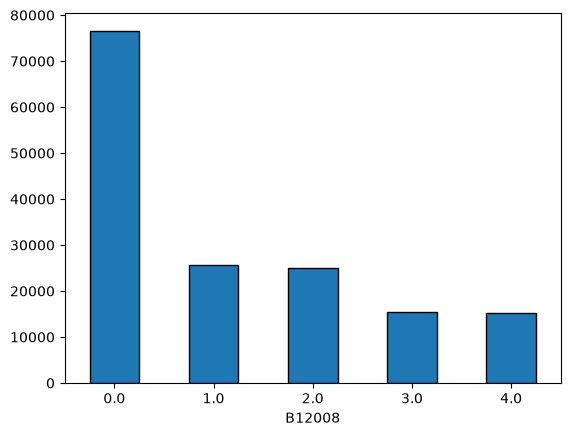

In [7]:
df['B12008'].value_counts().sort_index().plot(kind='bar', edgecolor='black', rot=0)

Imputação Simples de dados NaN

(Imputação é o processo de substituição de dados faltantes por valores substituídos.)

In [8]:
imputer = SimpleImputer(strategy='most_frequent')           # most_frequent = moda (valores mais comuns)
df_imputado_array = imputer.fit_transform(df)               # cria nova variável

df = pd.DataFrame(df_imputado_array, columns=df.columns)    # constrói novo data frame

In [9]:
def column_replace(df, column_name, old_value, new_value):
    df[column_name] = df[column_name].replace(old_value, new_value)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157721 entries, 0 to 157720
Columns: 199 entries, REGIAO to E01P27A
dtypes: float64(199)
memory usage: 239.5 MB


In [11]:
def remover_correlacao(df, threshold):
    corr_matrix = df.corr(numeric_only=True).abs()

    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Variáveis a remover (correlação > 0.8)
    to_drop = [
        column for column in upper.columns
        if any(upper[column] > threshold)
    ]

    print("Variáveis removidas:", to_drop)

    # Novo DataFrame
    df_reduzido = df.drop(columns=to_drop)

    return df_reduzido

In [12]:
df = remover_correlacao(df, 0.9)

Variáveis removidas: ['UF', 'B09013B']


Juntando as classes

0 = Saúdavel

1 = Ideação leve

2 = Ideação grave

In [13]:
column_replace(df, "B12008", 2, 1)
column_replace(df, "B12008", 3, 2)
column_replace(df, "B12008", 4, 2)

In [14]:
# Função para executar modelos

def models(df, column_name):
    X = df.drop(column_name, axis=1)
    y = df[column_name]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    # Hiperparametros já otimizados
    xgb = XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        subsample=0.8,
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        gamma=0.1,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb.fit(X_train, y_train)

    pred_xgb = xgb.predict(X_test)

    print("\n================ XGBOOST ================")
    print("Accuracy:", accuracy_score(y_test, pred_xgb))
    print(classification_report(y_test, pred_xgb))


    lightgbm = lgb.LGBMClassifier(
      n_estimators=200,
      learning_rate=0.05,
      num_leaves=31,
      random_state=42
    )

    lightgbm.fit(X_train, y_train)

    pred_gbm = lightgbm.predict(X_test)

    print("\n================ LIGHTGBM ================")
    print("Accuracy:", accuracy_score(y_test, pred_gbm))
    print(classification_report(y_test, pred_gbm))

In [15]:
models(df, "B12008")

# resultados de baseline para ver se o modelo melhorou ou não


================ XGBOOST ================
Accuracy: 0.6734823268346806
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.78     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.59      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048494 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 606
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 196
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

# Primeira parte (Análise)

Nessas parte é interessante fazer algumas análises para ver como os modelos se comportam com dados de alguns grupos para analisarmos o viés algoritmico e trabalhar com "justiça"

Então você vai treinar os modelos da seguinte forma

1. Treinar só com dados de uma região especifica
2. Treinar somente com dados de um tipo de escola (pública e privada)
3. Treinar somente com um sexo (Masculino e Feminino)
4. Fique a vontada para fazer mais testes

## Análise por micro região

Visualizando a distribuição das regiões no questionário

1: Norte

2: Nordeste

3: Sudeste

4: Sul

5: Centro-Oeste

<Axes: xlabel='REGIAO'>

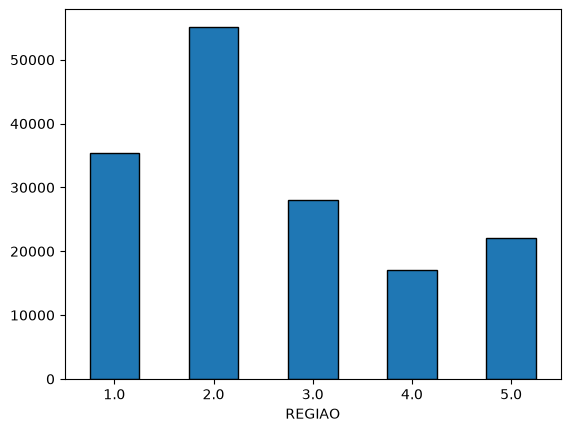

In [16]:
df['REGIAO'].value_counts().sort_index().plot(kind='bar', edgecolor='black', rot=0)

Criando DataFrames com as resposta de cada região

In [17]:
df_norte = df.query("REGIAO == 1.0")
df_nordeste = df.query("REGIAO == 2.0")
df_sudeste = df.query("REGIAO == 3.0")
df_sul = df.query("REGIAO == 4.0")
df_centro_oeste = df.query("REGIAO == 5.0")

Região Norte

In [18]:
models(df_norte, "B12008")


================ XGBOOST ================
Accuracy: 0.6560158348649795
              precision    recall  f1-score   support

         0.0       0.73      0.80      0.76      3327
         1.0       0.54      0.50      0.52      2316
         2.0       0.64      0.58      0.61      1430

    accuracy                           0.66      7073
   macro avg       0.64      0.63      0.63      7073
weighted avg       0.65      0.66      0.65      7073

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009615 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 28292, number of used features: 195
[LightGBM] [Info] Start training from score -0.768975
[LightGBM] [Info] Start training from score -1.137717
[LightGBM] [Info] Start training from score -1.532652

================ LIGHTGBM =====

Região Nordeste

In [19]:
models(df_nordeste, "B12008")


================ XGBOOST ================
Accuracy: 0.6703236920845045
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.78      5486
         1.0       0.54      0.51      0.53      3502
         2.0       0.67      0.56      0.61      2041

    accuracy                           0.67     11029
   macro avg       0.65      0.63      0.64     11029
weighted avg       0.67      0.67      0.67     11029

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017759 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 44115, number of used features: 195
[LightGBM] [Info] Start training from score -0.707646
[LightGBM] [Info] Start training from score -1.147100
[LightGBM] [Info] Start training from score -1.662624

================ LIGHTGBM =====

Região Sudeste

In [20]:
models(df_sudeste, "B12008")


================ XGBOOST ================
Accuracy: 0.6825707673135125
              precision    recall  f1-score   support

         0.0       0.75      0.82      0.78      2725
         1.0       0.56      0.53      0.54      1818
         2.0       0.69      0.60      0.64      1074

    accuracy                           0.68      5617
   macro avg       0.67      0.65      0.66      5617
weighted avg       0.68      0.68      0.68      5617

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009745 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 600
[LightGBM] [Info] Number of data points in the train set: 22466, number of used features: 195
[LightGBM] [Info] Start training from score -0.717568
[LightGBM] [Info] Start training from score -1.130864
[LightGBM] [Info] Start training from score -1.664378

================ LIGHTGBM =====

Região Sul

In [21]:
models(df_sul, "B12008")


================ XGBOOST ================
Accuracy: 0.6931185944363104
              precision    recall  f1-score   support

         0.0       0.77      0.81      0.79      1724
         1.0       0.58      0.58      0.58      1130
         2.0       0.67      0.58      0.62       561

    accuracy                           0.69      3415
   macro avg       0.67      0.65      0.66      3415
weighted avg       0.69      0.69      0.69      3415

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005987 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 13656, number of used features: 195
[LightGBM] [Info] Start training from score -0.694466
[LightGBM] [Info] Start training from score -1.114556
[LightGBM] [Info] Start training from score -1.756789

================ LIGHTGBM =====

Região Centro-Oeste

In [22]:
models(df_centro_oeste, "B12008")


================ XGBOOST ================
Accuracy: 0.6844968268359021
              precision    recall  f1-score   support

         0.0       0.77      0.81      0.79      2220
         1.0       0.52      0.52      0.52      1329
         2.0       0.70      0.61      0.65       863

    accuracy                           0.68      4412
   macro avg       0.67      0.65      0.65      4412
weighted avg       0.68      0.68      0.68      4412

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 599
[LightGBM] [Info] Number of data points in the train set: 17646, number of used features: 195
[LightGBM] [Info] Start training from score -0.736935
[LightGBM] [Info] Start training from score -1.138500
[LightGBM] [Info] Start training from score -1.603843

================ LIGHTGBM =====

## Análise por instuição de ensino

Visualizando a distribuição do tipo de instituição no questionário

0: Pública

1: Privada

<Axes: xlabel='DEP_ADMIN'>

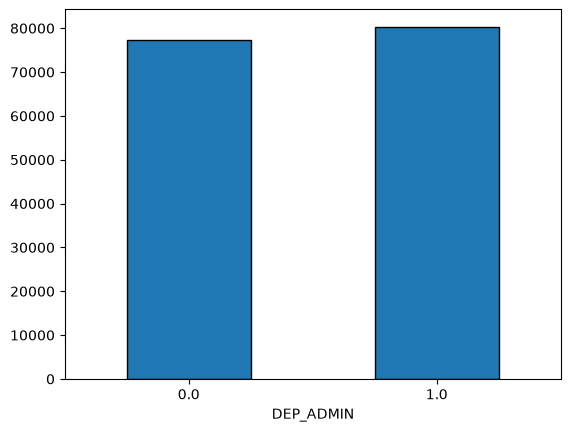

In [23]:
df['DEP_ADMIN'].value_counts().sort_index().plot(kind='bar', edgecolor='black', rot=0)

Criando DataFrames com as resposta de cada tipo de instituição

In [24]:
df_publica = df.query("DEP_ADMIN == 0.0")
df_privada = df.query("DEP_ADMIN == 1.0")

Escola Pública

In [25]:
models(df_publica, "B12008")


================ XGBOOST ================
Accuracy: 0.6864264496965
              precision    recall  f1-score   support

         0.0       0.76      0.82      0.79      7897
         1.0       0.56      0.54      0.55      5098
         2.0       0.67      0.56      0.61      2491

    accuracy                           0.69     15486
   macro avg       0.66      0.64      0.65     15486
weighted avg       0.68      0.69      0.68     15486

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 604
[LightGBM] [Info] Number of data points in the train set: 61942, number of used features: 195
[LightGBM] [Info] Start training from score -0.677990
[LightGBM] [Info] Start training from score -1.108509
[LightGBM] [Info] Start training from score -1.818228

================ LIGHTGBM ========

Escola Privada

In [26]:
models(df_privada, "B12008")


================ XGBOOST ================
Accuracy: 0.665483529485024
              precision    recall  f1-score   support

         0.0       0.73      0.80      0.77      7410
         1.0       0.54      0.49      0.51      5024
         2.0       0.68      0.62      0.65      3625

    accuracy                           0.67     16059
   macro avg       0.65      0.64      0.64     16059
weighted avg       0.66      0.67      0.66     16059

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018779 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 603
[LightGBM] [Info] Number of data points in the train set: 64234, number of used features: 195
[LightGBM] [Info] Start training from score -0.767689
[LightGBM] [Info] Start training from score -1.167301
[LightGBM] [Info] Start training from score -1.492946

================ LIGHTGBM ======

## Análise por sexo

B01001A - Qual é o seu sexo?

0 - Masculino

1 - Feminino




<Axes: xlabel='B01001A'>

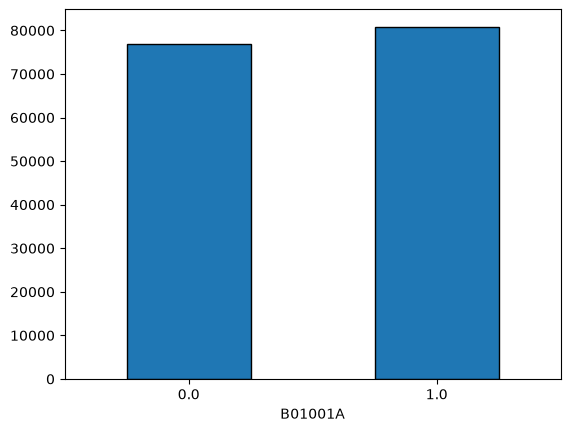

In [27]:
df['B01001A'].value_counts().sort_index().plot(kind='bar', edgecolor='black', rot=0)

Criando DataFrames com as resposta de cada gênero

In [28]:
df_masc = df.query("B01001A == 0.0")
df_femi = df.query("B01001A == 1.0")

Masculino

In [29]:
models(df_masc, "B12008")


================ XGBOOST ================
Accuracy: 0.6952678107124285
              precision    recall  f1-score   support

         0.0       0.76      0.88      0.82      9159
         1.0       0.52      0.42      0.46      4314
         2.0       0.61      0.45      0.52      1911

    accuracy                           0.70     15384
   macro avg       0.63      0.58      0.60     15384
weighted avg       0.68      0.70      0.68     15384

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 604
[LightGBM] [Info] Number of data points in the train set: 61532, number of used features: 195
[LightGBM] [Info] Start training from score -0.517271
[LightGBM] [Info] Start training from score -1.285227
[LightGBM] [Info] Start training from score -2.061467

================ LIGHTGBM =====

Feminino

In [30]:
models(df_femi, "B12008")


================ XGBOOST ================
Accuracy: 0.6523729967205
              precision    recall  f1-score   support

         0.0       0.72      0.72      0.72      6180
         1.0       0.55      0.58      0.57      5818
         2.0       0.70      0.65      0.68      4163

    accuracy                           0.65     16161
   macro avg       0.66      0.65      0.65     16161
weighted avg       0.66      0.65      0.65     16161

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 604
[LightGBM] [Info] Number of data points in the train set: 64644, number of used features: 195
[LightGBM] [Info] Start training from score -0.968591
[LightGBM] [Info] Start training from score -1.015946
[LightGBM] [Info] Start training from score -1.353546

================ LIGHTGBM ========

Analisando meninos de escola publica e privada

Criando DataFrames

In [31]:
df_masc_escola_publica = df.query("B01001A == 0.0 and DEP_ADMIN == 0.0")
df_masc_escola_privada = df.query("B01001A == 0.0 and DEP_ADMIN == 1.0")

In [32]:
models(df_masc_escola_publica, "B12008")


================ XGBOOST ================
Accuracy: 0.7117886713102904
              precision    recall  f1-score   support

         0.0       0.78      0.88      0.83      4611
         1.0       0.55      0.46      0.50      2165
         2.0       0.61      0.44      0.51       833

    accuracy                           0.71      7609
   macro avg       0.65      0.59      0.61      7609
weighted avg       0.70      0.71      0.70      7609

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012506 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 602
[LightGBM] [Info] Number of data points in the train set: 30432, number of used features: 194
[LightGBM] [Info] Start training from score -0.491151
[LightGBM] [Info] Start training from score -1.278256
[LightGBM] [Info] Start training from score -2.211322

================ LIGHTGBM =====

In [33]:
models(df_masc_escola_privada, "B12008")


================ XGBOOST ================
Accuracy: 0.6760128617363345
              precision    recall  f1-score   support

         0.0       0.74      0.87      0.80      4503
         1.0       0.51      0.40      0.45      2174
         2.0       0.62      0.43      0.51      1098

    accuracy                           0.68      7775
   macro avg       0.62      0.57      0.59      7775
weighted avg       0.66      0.68      0.66      7775

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 601
[LightGBM] [Info] Number of data points in the train set: 31100, number of used features: 194
[LightGBM] [Info] Start training from score -0.541020
[LightGBM] [Info] Start training from score -1.295026
[LightGBM] [Info] Start training from score -1.938255

================ LIGHTGBM =====

Analisando meninas de escola publica e privada

Criando DataFrames

In [34]:
df_femi_escola_publica = df.query("B01001A == 1.0 and DEP_ADMIN == 0.0")
df_femi_escola_privada = df.query("B01001A == 1.0 and DEP_ADMIN == 1.0")

In [35]:
models(df_femi_escola_publica, "B12008")


================ XGBOOST ================
Accuracy: 0.6620969789286621
              precision    recall  f1-score   support

         0.0       0.75      0.73      0.74      3269
         1.0       0.57      0.63      0.60      2961
         2.0       0.69      0.59      0.64      1648

    accuracy                           0.66      7878
   macro avg       0.67      0.65      0.66      7878
weighted avg       0.67      0.66      0.66      7878

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 602
[LightGBM] [Info] Number of data points in the train set: 31509, number of used features: 194
[LightGBM] [Info] Start training from score -0.897786
[LightGBM] [Info] Start training from score -0.970379
[LightGBM] [Info] Start training from score -1.543698

================ LIGHTGBM =====

In [36]:
models(df_femi_escola_privada, "B12008")


================ XGBOOST ================
Accuracy: 0.6339932399806857
              precision    recall  f1-score   support

         0.0       0.68      0.70      0.69      2892
         1.0       0.54      0.53      0.54      2923
         2.0       0.69      0.68      0.68      2469

    accuracy                           0.63      8284
   macro avg       0.64      0.64      0.64      8284
weighted avg       0.63      0.63      0.63      8284

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 601
[LightGBM] [Info] Number of data points in the train set: 33134, number of used features: 194
[LightGBM] [Info] Start training from score -1.039263
[LightGBM] [Info] Start training from score -1.067034
[LightGBM] [Info] Start training from score -1.196476

================ LIGHTGBM =====

B01002 - Qual é a sua cor ou raça?

0 - Branca

1 - Preta

2 - Amarela

3 - Parda

4 - Indígena

##### [[    verificar esses dados  ]]

<Axes: xlabel='B01002'>

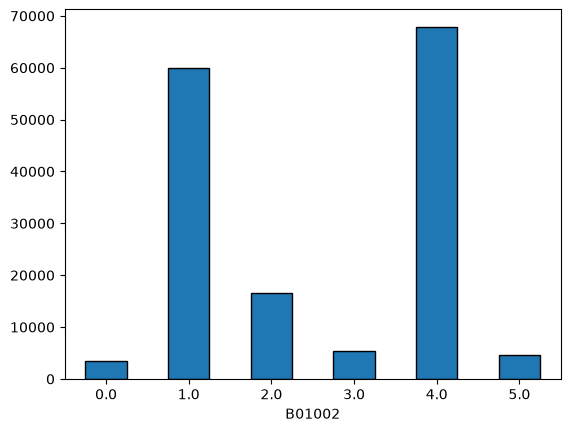

In [37]:
df['B01002'].value_counts().sort_index().plot(kind='bar', edgecolor='black', rot=0)

# Segunda parte (Ablação)

A ablação consiste em tirar parte dos modelos para verificar como funcionam, abaixo alguns artigos

- https://ieeexplore.ieee.org/abstract/document/10724733
- https://arxiv.org/abs/2207.05566
- Caso queria mais exemplos sugiro pesquisar no google academico ("ablation study" "machine learning") e anotar referências para escrevermos o artigo

Como você deve lembrar nossa base dados tem divisões como saúde mental, alimentação, atividade física, entre outras

Essa parte vai focar em remover todas as váriaveis de determinada divisão e testar para ver como o modelo performa, por exemplo, tirar todos os dados de alimentação e ver se o modelo piorou ou melhorou

Abaixo a lista de divisões que temos


-  B1 (Informações Gerais)
-  B2 (Alimentação)
-  B3 (Atividade Fisíca)
-  B4 (Uso de Cigarro)
-  B5 (Bebidas Alcoolicas)
-  B6 (Outras Drogas)
-  B7 (Situações em casa ou na escola)
-  B8 (Saúde Sexual e Reprodutiva) (Cuidado para não remover a várivel alvo)
-  B9 (Segurança)
-  B10 (Higiene e Saúde Bucal)
-  B11 (Imagem Corporal)
-  B12 (Saúde Mental)
-  B13 (Uso do Serviço de Saúde)
-  B16 (Sua Opinião)
- Váriaveis Derivadas
- EP (Questionário da Escola) "Pode remover todas as váriaveis dessa divisão"

Removendo B1 - Informações Gerais

In [40]:
variaveis_B1 = df.columns[df.columns.str.startswith('B01')]

df_sem_B1 = df.drop(columns=variaveis_B1)

In [64]:
variaveis_B1

Index(['B01001A', 'B01003', 'B01002', 'B01026A2', 'B01006', 'B01007',
       'B01010A', 'B01014', 'B01015B', 'B01016', 'B01017', 'B01018A',
       'B01019A', 'B01020A', 'B01008B'],
      dtype='str')

In [41]:
models(df_sem_B1, "B12008")


================ XGBOOST ================
Accuracy: 0.6730702171501031
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.78     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.58      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043575 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 554
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 181
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B2 - Alimentação

In [43]:
variaveis_B2 = df.columns[df.columns.str.startswith('B02')]

df_sem_B2 = df.drop(columns=variaveis_B2)

In [66]:
variaveis_B2

Index(['B02019A', 'B02017A', 'B02018B', 'B02028', 'B02029', 'B02030', 'B02031',
       'B02032', 'B02033', 'B02034', 'B02035', 'B02036', 'B02037', 'B02038',
       'B02039', 'B02040', 'B02001', 'B02004B', 'B02010A', 'B02011', 'B02013',
       'B02023A', 'B02021A', 'B02020B', 'B02041', 'B02042'],
      dtype='str')

In [44]:
models(df_sem_B2, "B12008")


================ XGBOOST ================
Accuracy: 0.6744333491837058
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.78     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.59      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043926 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 505
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 170
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B3 - Atividade Fisíca

In [45]:
variaveis_B3 = df.columns[df.columns.str.startswith('B03')]

df_sem_B3 = df.drop(columns=variaveis_B3)

In [57]:
variaveis_B3

Index(['B03001A1', 'B03001A2', 'B03003A', 'B03005B', 'B03006B', 'B03007A',
       'B03009B', 'B03010B'],
      dtype='str')

In [46]:
models(df_sem_B3, "B12008")


================ XGBOOST ================
Accuracy: 0.6739895387541607
              precision    recall  f1-score   support

         0.0       0.75      0.81      0.78     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.59      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044966 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 558
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 188
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B4 - Uso de Cigarro

In [47]:
variaveis_B4 = df.columns[df.columns.str.startswith('B04')]

df_sem_B4 = df.drop(columns=variaveis_B4)

In [58]:
variaveis_B4

Index(['B04001', 'B04010', 'B04013', 'B04014', 'B04015', 'B04006B', 'B04005A',
       'B04016'],
      dtype='str')

In [72]:
models(df_sem_B4, "B12008")


================ XGBOOST ================
Accuracy: 0.6743699476937708
              precision    recall  f1-score   support

         0.0       0.75      0.81      0.78     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.59      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 590
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 188
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B5 - Bebidas Alcoolicas

In [49]:
variaveis_B5 = df.columns[df.columns.str.startswith('B05')]

df_sem_B5 = df.drop(columns=variaveis_B5)

In [67]:
variaveis_B5

Index(['B05002A', 'B05007', 'B05011', 'B05010A'], dtype='str')

In [73]:
models(df_sem_B5, "B12008")


================ XGBOOST ================
Accuracy: 0.6732287208749406
              precision    recall  f1-score   support

         0.0       0.75      0.81      0.78     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.58      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 595
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 192
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B6 - Outras Drogas

In [51]:
variaveis_B6 = df.columns[df.columns.str.startswith('B06')]

df_sem_B6 = df.drop(columns=variaveis_B6)

In [53]:
variaveis_B6

Index(['B06001', 'B06006A'], dtype='str')

In [74]:
models(df_sem_B6, "B12008")


================ XGBOOST ================
Accuracy: 0.6738944365192582
              precision    recall  f1-score   support

         0.0       0.75      0.81      0.78     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.58      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045834 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 602
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 194
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B7 - Situações em casa ou na escola

In [69]:
variaveis_B7 = df.columns[df.columns.str.startswith('B07')]

df_sem_B7 = df.drop(columns=variaveis_B7)

In [70]:
variaveis_B7

Index(['B07001', 'B07002', 'B07004', 'B07006', 'B07007A', 'B07008', 'B07011',
       'B07012', 'B07013', 'B07009'],
      dtype='str')

In [75]:
models(df_sem_B7, "B12008")


================ XGBOOST ================
Accuracy: 0.6738627357742907
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.78     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.59      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045379 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 571
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 186
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B8 - Saúde Sexual e Reprodutiva

In [76]:
variaveis_B8 = df.columns[df.columns.str.startswith('B08')]

df_sem_B8 = df.drop(columns=variaveis_B8)

In [77]:
variaveis_B8

Index(['B08001', 'B08011A', 'B08006A', 'B08015', 'B08008A', 'B08009A',
       'B08010A'],
      dtype='str')

In [78]:
models(df_sem_B8, "B12008")


================ XGBOOST ================
Accuracy: 0.6747186558884134
              precision    recall  f1-score   support

         0.0       0.75      0.81      0.78     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.59      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 592
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 189
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B9 - Segurança

In [80]:
variaveis_B9 = df.columns[df.columns.str.startswith('B09')]

df_sem_B9 = df.drop(columns=variaveis_B9)

In [82]:
variaveis_B9

Index(['B09006A1', 'B09006A2', 'B09007A', 'B09008', 'B09009', 'B09019',
       'B09001', 'B09002', 'B09011A', 'B09012A1', 'B09012A2', 'B09012A3',
       'B09014B', 'B09003A', 'B09010A1', 'B09010A202', 'B09016A1', 'B09016A2'],
      dtype='str')

In [83]:
models(df_sem_B9, "B12008")


================ XGBOOST ================
Accuracy: 0.6724679029957203
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.77     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.58      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.64     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 551
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 178
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B10 - Higiene e Saúde Bucal

In [84]:
variaveis_B10 = df.columns[df.columns.str.startswith('B10')]

df_sem_B10 = df.drop(columns=variaveis_B10)

In [85]:
variaveis_B10

Index(['B10004A', 'B10005A', 'B10006A', 'B10001B', 'B10002', 'B10003'], dtype='str')

In [86]:
models(df_sem_B10, "B12008")


================ XGBOOST ================
Accuracy: 0.6738310350293232
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.78     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.59      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046233 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 583
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 190
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B11 - Imagem Corporal

In [87]:
variaveis_B11 = df.columns[df.columns.str.startswith('B11')]

df_sem_B11 = df.drop(columns=variaveis_B11)

In [88]:
variaveis_B11

Index(['B11007', 'B11001', 'B11002'], dtype='str')

In [89]:
models(df_sem_B11, "B12008")


================ XGBOOST ================
Accuracy: 0.6725947059755905
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.77     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.59      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047733 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 594
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 193
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B12 - Saúde Mental (menos a variável alvo)

In [ ]:
variaveis_B12 = df.columns[(df.columns.str.startswith('B12')) & (df.columns != 'B12008')]

df_sem_B12 = df.drop(columns=variaveis_B12)

In [96]:
variaveis_B12

Index(['B12003', 'B12004', 'B12005', 'B12006', 'B12007'], dtype='str')

In [97]:
models(df_sem_B12, "B12008")


================ XGBOOST ================
Accuracy: 0.6105880488191473
              precision    recall  f1-score   support

         0.0       0.67      0.81      0.74     15441
         1.0       0.48      0.40      0.44     10106
         2.0       0.60      0.44      0.51      5998

    accuracy                           0.61     31545
   macro avg       0.58      0.55      0.56     31545
weighted avg       0.60      0.61      0.60     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042660 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 583
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 191
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B13 - Uso do Serviço de Saúde

In [98]:
variaveis_B13 = df.columns[df.columns.str.startswith('B13')]

df_sem_B13 = df.drop(columns=variaveis_B13)

In [99]:
variaveis_B13

Index(['B13005', 'B13006', 'B13001', 'B13002A', 'B13003A', 'B13009A'], dtype='str')

In [100]:
models(df_sem_B13, "B12008")


================ XGBOOST ================
Accuracy: 0.6733872245997781
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.78     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.59      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048905 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 586
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 190
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo B16 -  Sua Opinião

In [101]:
variaveis_B16 = df.columns[df.columns.str.startswith('B16')]

df_sem_B16 = df.drop(columns=variaveis_B16)

In [102]:
variaveis_B16

Index(['B16001A01', 'B16001A04', 'B16001A05', 'B16001A06'], dtype='str')

In [103]:
models(df_sem_B16, "B12008")


================ XGBOOST ================
Accuracy: 0.6733555238548106
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.77     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.58      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048555 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 598
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 192
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo Váriaveis Derivadas

In [104]:
variaveis_derivadas = df.columns[df.columns.str.startswith('TEMPO')]

df_sem_derivadas = df.drop(columns=variaveis_derivadas)

In [105]:
variaveis_derivadas

Index(['TEMPOEDFIS', 'TEMPOEXTRA', 'TEMPOTOTAL'], dtype='str')

In [107]:
models(df_sem_derivadas, "B12008")


================ XGBOOST ================
Accuracy: 0.6732921223648756
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.77     15441
         1.0       0.54      0.52      0.53     10106
         2.0       0.69      0.58      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050305 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 594
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 193
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

Removendo EP - Questionário da Escola

In [108]:
variaveis_escola = df.columns[df.columns.str.startswith('E0')]

df_sem_escola = df.drop(columns=variaveis_escola)

In [109]:
variaveis_escola

Index(['E01P29', 'E01P30A02', 'E01P30A03', 'E01P03A01', 'E01P03A02',
       'E01P03A03', 'E01P03A04', 'E01P05B', 'E01P33A', 'E01P09A', 'E01P10B',
       'E01P7301', 'E01P7302', 'E01P7303', 'E01P7304', 'E01P7305', 'E01P7306',
       'E01P34', 'E01P7502', 'E01P7504', 'E01P7505', 'E01P7506', 'E01P7507',
       'E01P22A', 'E01P19A', 'E01P38A', 'E01P77', 'E01P11A', 'E01P12B01',
       'E01P12B02', 'E01P12B03', 'E01P12B04', 'E01P12B05', 'E01P12B07',
       'E01P12B08', 'E01P12B09', 'E01P12B10', 'E01P12B11', 'E01P13A', 'E01P78',
       'E01P49', 'E01P51', 'E01P57', 'E01P58A1', 'E01P58A2', 'E01P79',
       'E01P80', 'E01P81', 'E01P82', 'E01P83', 'E01P84', 'E01P60', 'E01P8501',
       'E01P8502', 'E01P8503', 'E01P8504', 'E01P8505', 'E01P8506', 'E01P8507',
       'E01P8508', 'E01P8509', 'E01P8510', 'E01P8511', 'E01P64A', 'E01P65A',
       'E01P66A', 'E01P26A', 'E01P27A'],
      dtype='str')

In [110]:
models(df_sem_escola, "B12008")


================ XGBOOST ================
Accuracy: 0.6748454588682834
              precision    recall  f1-score   support

         0.0       0.75      0.81      0.78     15441
         1.0       0.55      0.52      0.53     10106
         2.0       0.69      0.59      0.63      5998

    accuracy                           0.67     31545
   macro avg       0.66      0.64      0.65     31545
weighted avg       0.67      0.67      0.67     31545

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029305 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 126176, number of used features: 128
[LightGBM] [Info] Start training from score -0.724839
[LightGBM] [Info] Start training from score -1.137611
[LightGBM] [Info] Start training from score -1.634687

================ LIGHTGBM ====

In [ ]:
# Resumo accuracy
# B1 - XGBOOST: 0.6730702171501031  LIGHTGBM: 0.6723728007608178
# B2 - XGBOOST: 0.6744333491837058  LIGHTGBM: 0.6741480424789983
# B3 - XGBOOST: 0.6739895387541607  LIGHTGBM: 0.6739578380091932
# B4 - XGBOOST: 0.6743699476937708  LIGHTGBM: 0.6735774290695832
# B5 - XGBOOST: 0.6732287208749406  LIGHTGBM: 0.6744333491837058
# B6 - XGBOOST: 0.6738944365192582  LIGHTGBM: 0.6746869551434459
# B7 - XGBOOST: 0.6738627357742907  LIGHTGBM: 0.6724362022507528
# B8 - XGBOOST: 0.6747186558884134  LIGHTGBM: 0.6732921223648756
# B9 - XGBOOST: 0.6724679029957203  LIGHTGBM: 0.6719289903312727
# B10 - XGBOOST: 0.6738310350293232  LIGHTGBM: 0.6743382469488033
# B11 - XGBOOST: 0.6725947059755905  LIGHTGBM: 0.672816611190363
# B12 - XGBOOST: 0.6105880488191473  LIGHTGBM: 0.6104612458392772 *************
# B13 - XGBOOST: 0.6733872245997781  LIGHTGBM: 0.6726581074655255
# B16 - XGBOOST: 0.6733555238548106  LIGHTGBM: 0.6741797432239658
# Der - XGBOOST: 0.6732921223648756  LIGHTGBM: 0.6741797432239658
# EP - XGBOOST: 0.6748454588682834  LIGHTGBM: 0.6739261372642257